# 1. Project overview

This recovered notebook documents the fixed ICA2 pancreas batch-correction benchmark on a processed human pancreas scRNA-seq dataset. The main report compares `Uncorrected`, `Harmony`, `Scanorama`, `Seurat RPCA`, and exploratory `CONCORD` using batch ASW, batch mixing score, cell-type ASW, Leiden ARI, and Leiden NMI.

The intended run order is: load the processed AnnData object, inspect what is stored in it, apply the fixed benchmark filtering, build the uncorrected baseline, run method-specific integrations, compute benchmark metrics, inspect sensitivity on stored embeddings, and save the final report inputs and figures.

Use `results/benchmark_metrics.csv` as the source of truth for final metric values if any rendered notebook outputs disagree with saved tables.


# 2. Load processed pancreas data

Start from the recovered processed pancreas object so every downstream method uses the same baseline input.


In [4]:
# Import the core Python stack used throughout the documented benchmark workflow.
import omicverse as ov
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("omicverse:", ov.__version__)
print("scanpy:", sc.__version__)


omicverse: 2.1.2
scanpy: 1.11.5


/tmp/ipykernel_2263328/2749626309.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


In [5]:
# Load the processed pancreas object that all downstream benchmark steps start from.
adata = sc.read_h5ad("data/pancreas.h5ad")

batch_key = "batch"
label_key = "celltype"

print("Loaded AnnData:", adata)
print("Shape:", adata.shape)
print("obs columns:", list(adata.obs.columns))
print("Available layers:", list(adata.layers.keys()))
print("Raw counts available:", adata.raw is not None)
print(adata.obs[batch_key].value_counts())
print(adata.obs[label_key].value_counts())


/home/training/mambaforge/envs/rapids1_ica2/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/training/mambaforge/envs/rapids1_ica2/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Index(['celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'], dtype='object')
batch
0    8569
2    3363
1    2126
3     635
Name: count, dtype: int64
celltype
alpha                     4214
beta                      3354
ductal                    1804
acinar                    1368
not applicable            1154
delta                      917
gamma                      571
endothelial                289
activated_stellate         284
dropped                    178
quiescent_stellate         173
mesenchymal                 80
macrophage                  55
PSC                         54
unclassified endocrine      41
co-expression          

# 3. Inspect matrix and metadata

These checks make the stored matrix, layers, and metadata explicit before any filtering or cross-language export steps.


In [40]:
# Check whether the recovered matrix looks count-like before methods that assume counts or stored raw values.
from scipy import sparse
import numpy as np

X = adata.X

if sparse.issparse(X):
    values = X.data
else:
    values = X.ravel()

print("Min:", values.min())
print("Max:", values.max())
print("Any negative values:", np.any(values < 0))
print("Fraction integer-like:", np.mean(np.isclose(values, np.round(values))))
print("Available layers:", list(adata.layers.keys()))
print("Raw counts available:", adata.raw is not None)
if adata.raw is not None:
    raw_x = adata.raw.X
    raw_values = raw_x.data if sparse.issparse(raw_x) else np.asarray(raw_x).ravel()
    print("Raw min:", raw_values.min())
    print("Raw max:", raw_values.max())
    print("Raw any negative values:", np.any(raw_values < 0))


Min: -1.7307595
Max: 10.0
Any negative values: True
Fraction integer-like: 0.0010304304348386964
Layers: KeysView(Layers with keys: )


In [41]:
# Summarize per-batch QC fields so obvious metadata problems are visible before filtering.
import pandas as pd

qc_summary = adata.obs.groupby(batch_key)[["n_genes", "n_counts"]].describe()
qc_summary


      n_genes                                                                 \
        count          mean          std      min      25%      50%      75%   
batch                                                                          
0      8569.0   1887.240518   620.413251    767.0   1437.0   1847.0   2259.0   
1      2126.0   5156.009878  1398.957599   1890.0   4146.5   5091.5   6038.0   
2      3363.0   4704.903657  2852.917383    202.0   1811.0   5232.0   7145.0   
3       635.0  19950.000000     0.000000  19950.0  19950.0  19950.0  19950.0   

               n_counts                                             \
           max    count          mean           std            min   
batch                                                                
0       4922.0   8569.0  5.827295e+03  3.418063e+03    1201.000000   
1      12207.0   2126.0  2.189395e+04  1.580381e+04    6033.291016   
2      12213.0   3363.0  3.265920e+05  4.484926e+05     225.000000   
3      19950.0    6

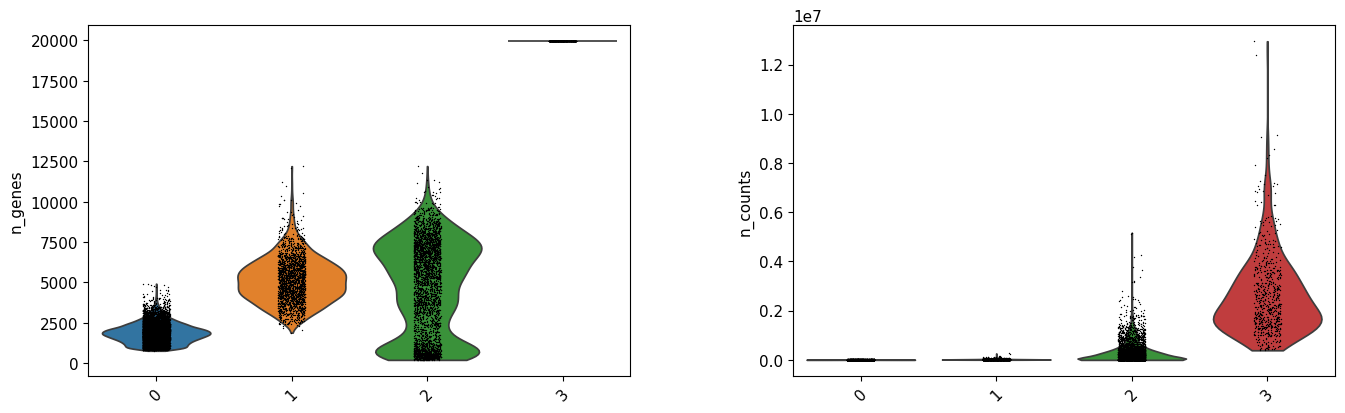

In [42]:
sc.pl.violin(
    adata,
    keys=["n_genes", "n_counts"],
    groupby=batch_key,
    rotation=45,
    multi_panel=True
)

### Optional matrix inspection snippets

These small checks are kept for debugging recovered inputs and for confirming whether a matrix looks count-like or already transformed.


In [56]:
# Quick matrix sanity check on the loaded object; kept for debugging recovered inputs.
import numpy as np
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = np.asarray(X).ravel()

vals = vals[np.isfinite(vals)]

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("has negative:", np.any(vals < 0))
print("integer-like:", np.allclose(vals[:100000], np.round(vals[:100000])))

print("layers:", adata.layers.keys())
print("raw exists:", adata.raw is not None)


min: -1.7307595
max: 10.0
mean: -0.0048582777
has negative: True
integer-like: False
layers: KeysView(Layers with keys: )
raw exists: True


In [57]:
# Reload the file and inspect both X and raw.X so later export choices are easier to justify.
from scipy import sparse
import numpy as np
import scanpy as sc

adata0 = sc.read_h5ad("data/pancreas.h5ad")

def inspect_matrix(name, X, n=100000):
    if sparse.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    vals = vals[np.isfinite(vals)]
    vals_sample = vals[:min(n, len(vals))]

    print("\n", name)
    print("shape:", X.shape)
    print("min:", vals.min())
    print("max:", vals.max())
    print("mean:", vals.mean())
    print("has negative:", np.any(vals < 0))
    print("integer-like:", np.allclose(vals_sample, np.round(vals_sample)))
    print("number of nonzero values checked:", len(vals_sample))

inspect_matrix("adata0.X", adata0.X)

print("\nraw exists:", adata0.raw is not None)

if adata0.raw is not None:
    inspect_matrix("adata0.raw.X", adata0.raw.X)



 adata0.X
shape: (14693, 2448)
min: -1.7307595
max: 10.0
mean: -0.0048582777
has negative: True
integer-like: False
number of nonzero values checked: 100000

raw exists: True

 adata0.raw.X
shape: (14693, 24516)
min: 0.08214879
max: 15.350667
mean: 1.580624
has negative: False
integer-like: False
number of nonzero values checked: 100000


# 4. Filter ambiguous annotations and rare cell types

Apply the fixed benchmark filtering once so every correction method is evaluated on the same cleaned cells and labels.


In [6]:
# Filter labels once here so all methods and all metrics use the same benchmark cohort.
adata_work = adata.copy()

bad_labels = [
    "not applicable",
    "dropped",
    "unclear",
    "unclassified",
    "co-expression"
]

adata_work = adata_work[
    ~adata_work.obs[label_key].isin(bad_labels)
].copy()

# Remove particularly rare cell types to reduce instability in silhouette and clustering metrics.
celltype_counts = adata_work.obs[label_key].value_counts()
keep_celltypes = celltype_counts[celltype_counts >= 20].index

adata_work = adata_work[
    adata_work.obs[label_key].isin(keep_celltypes)
].copy()

print("Filtered AnnData:", adata_work)
print("Filtered shape:", adata_work.shape)
print(adata_work.obs[batch_key].value_counts())
print(adata_work.obs[label_key].value_counts())


AnnData object with n_obs × n_vars = 13291 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
batch
0    8549
2    2163
1    2122
3     457
Name: count, dtype: int64
celltype
alpha                     4214
beta                      3354
ductal                    1804
acinar                    1368
delta                      917
gamma                      571
endothelial                289
activated_stellate         284
quiescent_stellate         173
mesenchymal                 80
macrophage                  55
PSC                         54
unclassified endocrine      41
mast                        32
epsilon                     28
mesenchyme                  27
Name: count, dtype: int64


In [43]:
# Print before/after counts so the benchmark filtering is transparent in the notebook output.
print("Before filtering:")
print(adata)
print(adata.obs[label_key].value_counts())

print("After filtering:")
print(adata_work)
print("Filtered shape:", adata_work.shape)
print(adata_work.obs[label_key].value_counts())
print(adata_work.obs[batch_key].value_counts())


Before filtering:
AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'batch_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
celltype
alpha                     4214
beta                      3354
ductal                    1804
acinar                    1368
not applicable            1154
delta                      917
gamma                      571
endothelial                289
activated_stellate         284
dropped                    178
quiescent_stellate         173
mesenchymal                 80
macrophage                  55
PSC                         54
unclassified endocrine      41
co-expression               39
mast                        32
epsilon                     28
mesenchyme                  27
schwann                   

In [ ]:
# Keep a compact table of the final benchmark cohort used by every downstream method.
filtering_summary = pd.DataFrame({
    "step": ["original", "after_benchmark_filtering"],
    "n_cells": [adata.n_obs, adata_work.n_obs],
    "n_genes": [adata.n_vars, adata_work.n_vars],
    "n_celltypes": [
        adata.obs[label_key].nunique(),
        adata_work.obs[label_key].nunique()
    ],
    "n_batches": [
        adata.obs[batch_key].nunique(),
        adata_work.obs[batch_key].nunique()
    ]
})

print("Final filtered AnnData shape:", adata_work.shape)
filtering_summary


                    step  n_cells  n_genes  n_celltypes  n_batches
0               original    14693     2448           24          4
1  after_label_filtering    13291     2448           16          4

# 5. Build uncorrected PCA/UMAP baseline

The uncorrected embedding is the reference baseline used for both visual comparison and downstream benchmarking.


In [45]:
# Build the fixed uncorrected reference embedding used for the main comparison panels and metrics.
adata_work.raw = adata_work

sc.pp.scale(adata_work, max_value=10)
sc.tl.pca(adata_work, n_comps=50, svd_solver="arpack")

sc.pp.neighbors(adata_work, use_rep="X_pca", n_neighbors=15)
sc.tl.umap(adata_work)

adata_work.obsm["X_umap_uncorrected"] = adata_work.obsm["X_umap"].copy()

print("Uncorrected PCA shape:", adata_work.obsm["X_pca"].shape)
print("Uncorrected UMAP shape:", adata_work.obsm["X_umap_uncorrected"].shape)


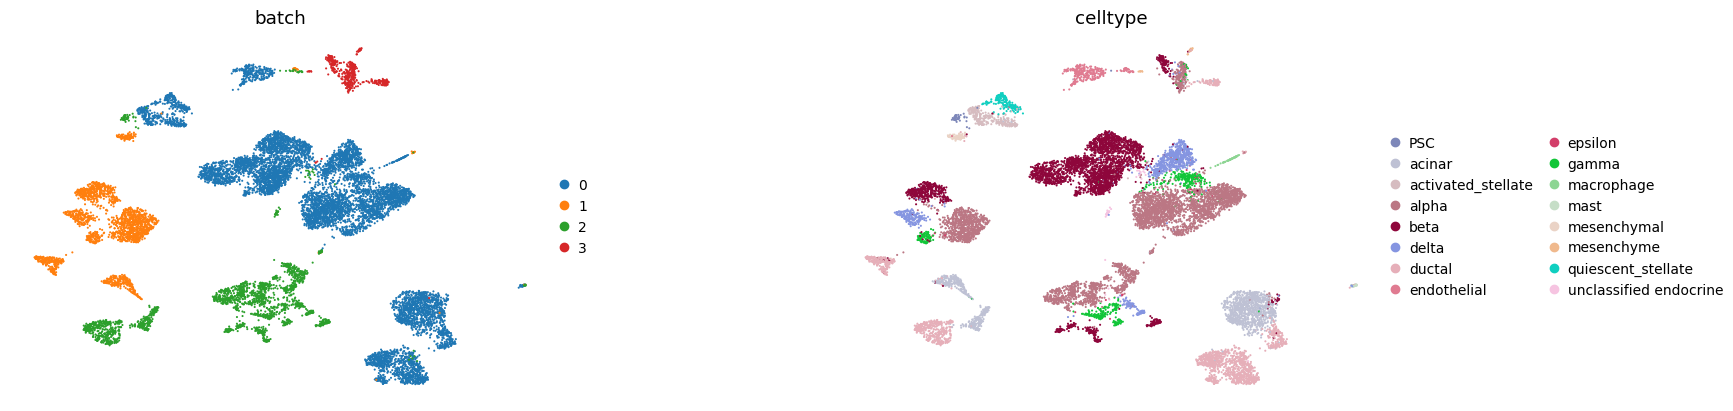

In [46]:
sc.pl.umap(
    adata_work,
    color=[batch_key, label_key],
    wspace=0.4,
    frameon=False
)

# 6. Run Harmony

Harmony is evaluated on the same filtered cells as the uncorrected baseline so the comparison stays cell-matched.


In [47]:
# Run a first Harmony pass to confirm the expected corrected representation is created.
adata_harmony = adata_work.copy()

ov.single.batch_correction(
    adata_harmony,
    batch_key=batch_key,
    methods="harmony",
    n_pcs=50
)

print(adata_harmony.obsm.keys())


...Begin using harmony to correct batch effect
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ndarray, shape: (13291, 2448), dtype: float32
   🔧 PCA solver used: covariance_eigh
    finished✅ (4.25s)
🚀 Using PyTorch CUDA acceleration for Harmony
    Data: 50 PCs × 13291 cells
    Batch variables: ['batch']
    Max iterations: 10
    Convergence threshold: 0.0001
    Initializing centroids (K=100) ... done
🔍 [2026-05-14 21:56:33] Running Harmony integration...


Harmony iteration 10/10: 100%|██████████| 10/10 [00:02<00:00,  4.76it/s]

⚠️ Harmony stopped before convergence after 10 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 10.3572s                                                │
│  Shape:    13,291 x 2,448 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│                                                                    │
│  ● OBSM   │ ✚ X_harmony (array, 13291x50)                          │
│           │ ✚ X_pca_harmony (array, 13291x50)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected, X_pca_harmony, X_harmon

In [48]:
# Re-run Harmony with the final iteration setting used for the stored benchmark outputs.
adata_harmony = adata_work.copy()

ov.single.batch_correction(
    adata_harmony,
    batch_key=batch_key,
    methods="harmony",
    n_pcs=50,
    max_iter_harmony=30
)

print(adata_harmony.obsm.keys())


...Begin using harmony to correct batch effect
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ndarray, shape: (13291, 2448), dtype: float32
   🔧 PCA solver used: covariance_eigh
    finished✅ (5.56s)
🚀 Using PyTorch CUDA acceleration for Harmony
    Data: 50 PCs × 13291 cells
    Batch variables: ['batch']
    Max iterations: 30
    Convergence threshold: 0.0001
    Initializing centroids (K=100) ... done
🔍 [2026-05-14 21:57:34] Running Harmony integration...


Harmony converged after 24 iterations:  77%|███████▋  | 23/30 [00:03<00:01,  6.78it/s]


✅ Harmony converged after 24 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 15.2279s                                                │
│  Shape:    13,291 x 2,448 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│                                                                    │
│  ● OBSM   │ ✚ X_harmony (array, 13291x50)                          │
│           │ ✚ X_pca_harmony (array, 13291x50)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected, X_pca_harmony, X_harmony)


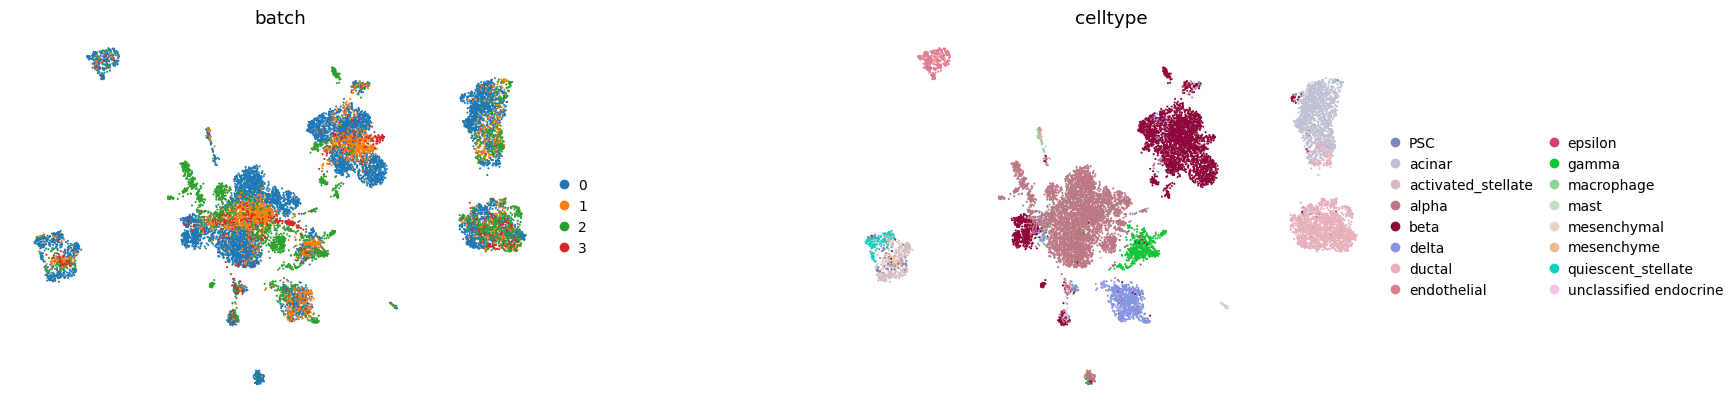

In [49]:
# Build the Harmony UMAP used in the comparison figures while keeping the corrected PCA for benchmarking.
sc.pp.neighbors(
    adata_harmony,
    use_rep="X_pca_harmony",
    n_neighbors=15
)

sc.tl.umap(adata_harmony, random_state=0)

adata_harmony.obsm["X_umap_harmony"] = adata_harmony.obsm["X_umap"].copy()

sc.pl.umap(
    adata_harmony,
    color=[batch_key, label_key],
    wspace=0.4,
    frameon=False
)


# 7. Run Scanorama

Scanorama is run on the same filtered object and then embedded for the final report figures.


In [50]:
# Run Scanorama on the same filtered object so the comparison stays strictly matched across methods.
adata_scanorama = adata_work.copy()

ov.single.batch_correction(
    adata_scanorama,
    batch_key=batch_key,
    methods="scanorama",
    n_pcs=50
)

print(adata_scanorama.obsm.keys())


...Begin using scanorama to correct batch effect
0
1
2
3
Found 2448 genes among all datasets
[[0.         0.18378888 0.13684697 0.02844639]
 [0.         0.         0.51083883 0.14442013]
 [0.         0.         0.         0.4463895 ]
 [0.         0.         0.         0.        ]]
Processing datasets (1, 2)
Processing datasets (2, 3)
Processing datasets (0, 1)
Processing datasets (1, 3)
Processing datasets (0, 2)
(13291, 50)

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 27.3726s                                                │
│  Shape:    13,291 x 2,448 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│                                                                    │
│ 

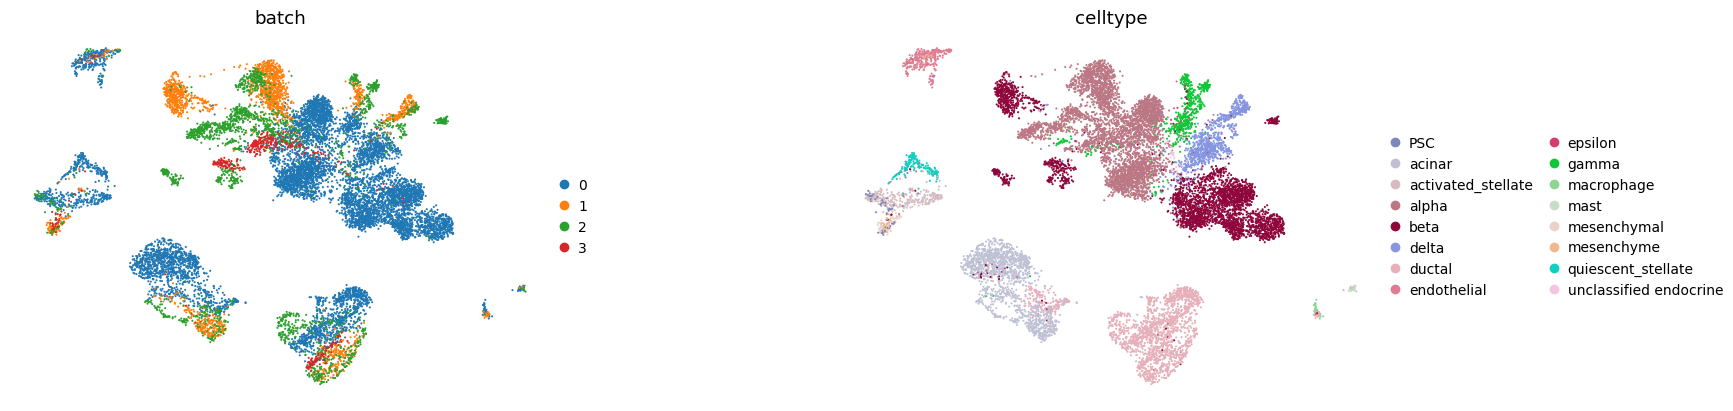

In [51]:
# Build the Scanorama UMAP for visual comparison while retaining the high-dimensional embedding for metrics.
sc.pp.neighbors(
    adata_scanorama,
    use_rep="X_scanorama",
    n_neighbors=15
)

sc.tl.umap(adata_scanorama, random_state=0)

adata_scanorama.obsm["X_umap_scanorama"] = adata_scanorama.obsm["X_umap"].copy()

sc.pl.umap(
    adata_scanorama,
    color=[batch_key, label_key],
    wspace=0.4,
    frameon=False
)


# 8. Export data for Seurat RPCA

Export the same filtered cells to R so the Seurat RPCA workflow can be run without changing the benchmark cohort.


In [19]:
# Export the filtered benchmark cohort to R while preserving the exact cell order used in Python.
import os
import scanpy as sc
import pandas as pd
from scipy import sparse
from scipy.io import mmwrite

batch_key = "batch"
label_key = "celltype"

adata_seurat = sc.read_h5ad("data/pancreas.h5ad")

bad_labels = [
    "not applicable",
    "dropped",
    "unclear",
    "unclassified",
    "co-expression"
]

adata_seurat = adata_seurat[
    ~adata_seurat.obs[label_key].isin(bad_labels)
].copy()

celltype_counts = adata_seurat.obs[label_key].value_counts()
keep_celltypes = celltype_counts[celltype_counts >= 20].index

adata_seurat = adata_seurat[
    adata_seurat.obs[label_key].isin(keep_celltypes)
].copy()

os.makedirs("seurat_input", exist_ok=True)

X = adata_seurat.X
if not sparse.issparse(X):
    X = sparse.csr_matrix(X)

# Seurat expects genes x cells, so the exported matrix is transposed here.
mmwrite("seurat_input/matrix.mtx", X.T)

pd.Series(adata_seurat.var_names).to_csv(
    "seurat_input/genes.tsv",
    sep="\t",
    index=False,
    header=False
)

pd.Series(adata_seurat.obs_names).to_csv(
    "seurat_input/barcodes.tsv",
    sep="\t",
    index=False,
    header=False
)

adata_seurat.obs[[batch_key, label_key]].to_csv(
    "seurat_input/metadata.csv"
)

print(adata_seurat)
print("Exported Seurat input files.")
for output_path in [
    "seurat_input/matrix.mtx",
    "seurat_input/genes.tsv",
    "seurat_input/barcodes.tsv",
    "seurat_input/metadata.csv",
]:
    print(output_path, os.path.exists(output_path))


AnnData object with n_obs × n_vars = 13291 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Exported Seurat input files.


# 9. Import Seurat RPCA results and check cell order

Bring the Seurat RPCA embeddings back into Python and verify exact cell alignment before benchmarking.


In [52]:
# Load the Seurat RPCA outputs and inspect their shapes before aligning them back to the notebook object.
import scanpy as sc
import pandas as pd
import numpy as np

batch_key = "batch"
label_key = "celltype"

seurat_pca = pd.read_csv("seurat_rpca_pca.csv", index_col=0)
seurat_umap = pd.read_csv("seurat_rpca_umap.csv", index_col=0)
seurat_meta = pd.read_csv("seurat_rpca_metadata.csv", index_col=0)

print("PCA shape:", seurat_pca.shape)
print("UMAP shape:", seurat_umap.shape)
print("Metadata shape:", seurat_meta.shape)

print(seurat_pca.head())
print(seurat_umap.head())
print(seurat_meta[[batch_key, label_key]].head())


(13291, 20)
(13291, 2)
(13291, 5)
                                   PC_1      PC_2      PC_3      PC_4  \
human1_lib1.final_cell_0001-0  1.530777 -2.463520  7.934544 -5.350066   
human1_lib1.final_cell_0002-0  4.197005 -3.820139  8.942748 -6.519071   
human1_lib1.final_cell_0003-0  0.012986 -1.644052  7.694173 -2.109788   
human1_lib1.final_cell_0004-0  3.480128 -3.424809  9.444114 -4.287403   
human1_lib1.final_cell_0005-0  2.001267 -2.076265  6.002590 -2.557631   

                                   PC_5      PC_6      PC_7      PC_8  \
human1_lib1.final_cell_0001-0  0.608984 -3.132784 -0.906220  3.184375   
human1_lib1.final_cell_0002-0  1.092777 -2.883636 -1.445582  1.630083   
human1_lib1.final_cell_0003-0  0.366612 -0.388224  0.388277  2.627687   
human1_lib1.final_cell_0004-0  1.453691 -2.723842  0.031656  0.584386   
human1_lib1.final_cell_0005-0 -0.997518  0.078091 -0.763778  1.790703   

                                   PC_9     PC_10     PC_11     PC_12  \
human1_lib1.fin

In [53]:
# Rebuild the exact filtered AnnData used for Seurat export so imported embeddings can be checked cell by cell.
adata_seurat = sc.read_h5ad("data/pancreas.h5ad")

bad_labels = [
    "not applicable",
    "dropped",
    "unclear",
    "unclassified",
    "co-expression"
]

adata_seurat = adata_seurat[
    ~adata_seurat.obs[label_key].isin(bad_labels)
].copy()

celltype_counts = adata_seurat.obs[label_key].value_counts()
keep_celltypes = celltype_counts[celltype_counts >= 20].index

adata_seurat = adata_seurat[
    adata_seurat.obs[label_key].isin(keep_celltypes)
].copy()

print(adata_seurat)
print("Rebuilt Seurat input shape:", adata_seurat.shape)
print(adata_seurat.obs[label_key].value_counts())


AnnData object with n_obs × n_vars = 13291 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
celltype
alpha                     4214
beta                      3354
ductal                    1804
acinar                    1368
delta                      917
gamma                      571
endothelial                289
activated_stellate         284
quiescent_stellate         173
mesenchymal                 80
macrophage                  55
PSC                         54
unclassified endocrine      41
mast                        32
epsilon                     28
mesenchyme                  27
Name: count, dtype: int64


In [54]:
# Check overlap and exact cell identity before reindexing imported Seurat outputs onto the notebook order.
seurat_pca.index = seurat_pca.index.astype(str)
seurat_umap.index = seurat_umap.index.astype(str)
seurat_meta.index = seurat_meta.index.astype(str)
adata_seurat.obs_names = adata_seurat.obs_names.astype(str)

print("Cells in AnnData:", adata_seurat.n_obs)
print("Cells in Seurat PCA:", seurat_pca.shape[0])
print("Cells in Seurat UMAP:", seurat_umap.shape[0])
print("Cells in Seurat metadata:", seurat_meta.shape[0])
print("Common cells with PCA:", len(set(adata_seurat.obs_names) & set(seurat_pca.index)))
print("Common cells with UMAP:", len(set(adata_seurat.obs_names) & set(seurat_umap.index)))
print("Exact order already matches PCA:", seurat_pca.index.equals(adata_seurat.obs_names))
print("Exact order already matches UMAP:", seurat_umap.index.equals(adata_seurat.obs_names))
print("Exact order already matches metadata:", seurat_meta.index.equals(adata_seurat.obs_names))

missing_in_pca = adata_seurat.obs_names.difference(seurat_pca.index)
missing_in_umap = adata_seurat.obs_names.difference(seurat_umap.index)
missing_in_meta = adata_seurat.obs_names.difference(seurat_meta.index)
if len(missing_in_pca) > 0 or len(missing_in_umap) > 0 or len(missing_in_meta) > 0:
    raise ValueError(
        "Imported Seurat outputs are missing cells from the filtered AnnData object. "
        f"PCA missing={len(missing_in_pca)}, UMAP missing={len(missing_in_umap)}, metadata missing={len(missing_in_meta)}"
    )


Cells in AnnData: 13291
Cells in Seurat PCA: 13291
Common cells: 13291


In [55]:
# Reindex imported Seurat embeddings to the notebook order so labels and coordinates remain cell-aligned.
seurat_pca = seurat_pca.loc[adata_seurat.obs_names]
seurat_umap = seurat_umap.loc[adata_seurat.obs_names]
seurat_meta = seurat_meta.loc[adata_seurat.obs_names]

if not seurat_pca.index.equals(adata_seurat.obs_names):
    raise ValueError("PCA cell order still does not match adata_seurat.obs_names after reindexing.")
if not seurat_umap.index.equals(adata_seurat.obs_names):
    raise ValueError("UMAP cell order still does not match adata_seurat.obs_names after reindexing.")
if not seurat_meta.index.equals(adata_seurat.obs_names):
    raise ValueError("Metadata cell order still does not match adata_seurat.obs_names after reindexing.")

adata_seurat_rpca = adata_seurat.copy()
adata_seurat_rpca.obsm["X_seurat_rpca"] = seurat_pca.values
adata_seurat_rpca.obsm["X_umap_seurat_rpca"] = seurat_umap.values

print("Exact PCA order after reindexing:", seurat_pca.index.equals(adata_seurat.obs_names))
print("Exact UMAP order after reindexing:", seurat_umap.index.equals(adata_seurat.obs_names))
print("Exact metadata order after reindexing:", seurat_meta.index.equals(adata_seurat.obs_names))
print(adata_seurat_rpca.obsm.keys())


KeysView(AxisArrays with keys: X_pca, X_umap, X_seurat_rpca, X_umap_seurat_rpca)


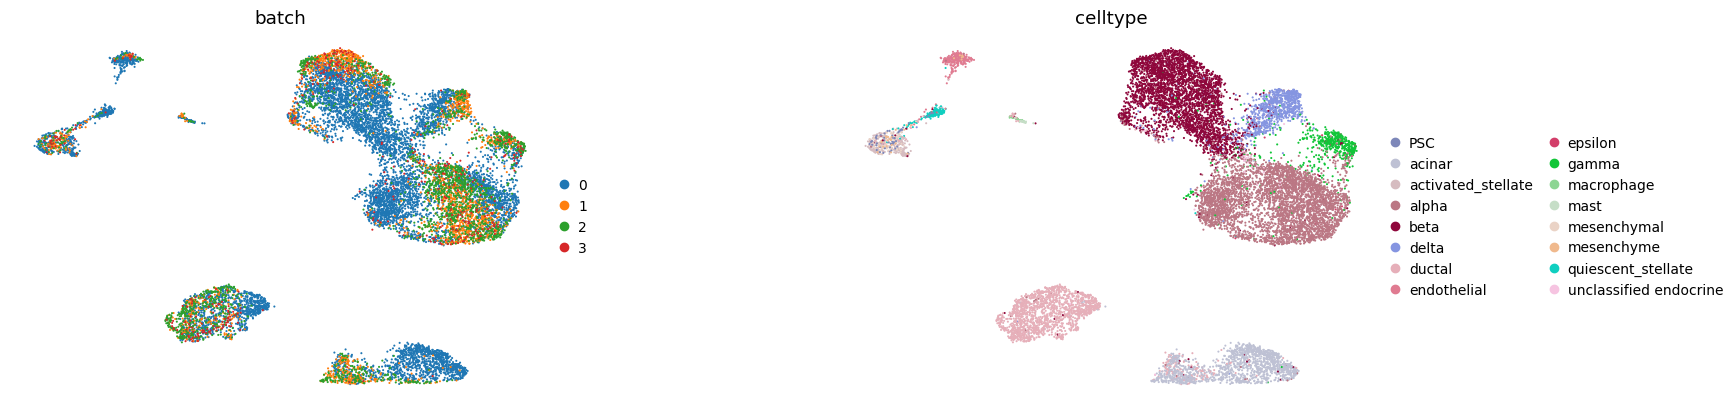

In [24]:
# Visualize the imported Seurat RPCA layout after order checks pass.
adata_seurat_rpca.obsm["X_umap"] = adata_seurat_rpca.obsm["X_umap_seurat_rpca"].copy()

sc.pl.umap(
    adata_seurat_rpca,
    color=[batch_key, label_key],
    wspace=0.4,
    frameon=False
)


# 10. Run exploratory CONCORD

CONCORD is kept as an exploratory comparison because it uses a 100-dimensional cosine representation rather than the 20-dimensional Euclidean setting used for the main methods.


In [58]:
# Run CONCORD on the same filtered cells as an exploratory comparison, keeping the result separate from the main 20D Euclidean benchmark.
import scanpy as sc
import numpy as np
import torch
import concord as ccd

adata0 = sc.read_h5ad("data/pancreas.h5ad")

# Use raw.X because adata0.X is scaled and contains negative values.
adata_concord = adata0.raw.to_adata().copy()

# Restrict to the same benchmark cells and shared genes used by the main comparison.
adata_concord = adata_concord[adata_work.obs_names].copy()
common_genes = adata_work.var_names.intersection(adata_concord.var_names)
print("Common genes:", len(common_genes))

adata_concord = adata_concord[:, common_genes].copy()
adata_concord.obs = adata_work.obs.copy()

print(adata_concord)
print("same cells:", adata_concord.obs_names.equals(adata_work.obs_names))
print("min:", adata_concord.X.min())
print("max:", adata_concord.X.max())

feature_list = list(adata_concord.var_names)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

try:
    cur_ccd = ccd.Concord(
        adata=adata_concord,
        input_feature=feature_list,
        domain_key=batch_key,
        device=device,
        preload_dense=False,
        use_faiss=False
    )
except TypeError:
    cur_ccd = ccd.Concord(
        adata=adata_concord,
        input_feature=feature_list,
        domain_key=batch_key,
        device=device,
        preload_dense=False
    )

cur_ccd.fit_transform(output_key="X_concord")

print(adata_concord.obsm.keys())


Common genes: 2448
AnnData object with n_obs × n_vars = 13291 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'
same cells: True
min: 0.0
max: 13.026035
device: cuda:0
Epoch 0 Training
Epoch 1 Training
Epoch 2 Training
Epoch 3 Training
Epoch 4 Training
Epoch 5 Training
Epoch 6 Training
Epoch 7 Training
Epoch 8 Training
Epoch 9 Training
Epoch 10 Training
Epoch 11 Training
Epoch 12 Training
Epoch 13 Training
Epoch 14 Training
KeysView(AxisArrays with keys: X_pca, X_umap, X_concord)


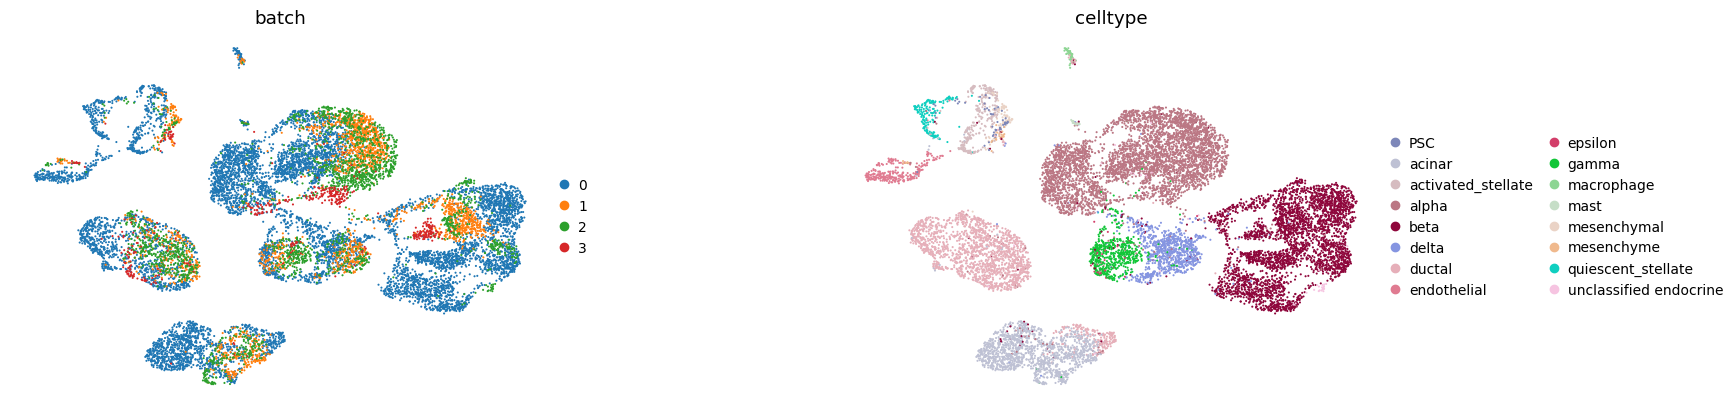

In [59]:
sc.pp.neighbors(
    adata_concord,
    use_rep="X_concord",
    n_neighbors=15,
    metric="cosine"
)

sc.tl.umap(adata_concord, random_state=0)

adata_concord.obsm["X_umap_concord"] = adata_concord.obsm["X_umap"].copy()

sc.pl.umap(
    adata_concord,
    color=[batch_key, label_key],
    wspace=0.4,
    frameon=False
)

# 11. Compute benchmark metrics

Benchmark all stored embeddings from the same filtered cell set, then save the final tables that feed the report and polished figures.


In [60]:
# Confirm that every method still refers to the same filtered cells before comparing metrics.
print("adata_work:", adata_work.n_obs, adata_work.obsm.keys())
print("adata_harmony:", adata_harmony.n_obs, adata_harmony.obsm.keys())
print("adata_scanorama:", adata_scanorama.n_obs, adata_scanorama.obsm.keys())
print("adata_seurat_rpca:", adata_seurat_rpca.n_obs, adata_seurat_rpca.obsm.keys())

use_concord = "adata_concord" in globals() and "X_concord" in adata_concord.obsm.keys()

if use_concord:
    print("adata_concord:", adata_concord.n_obs, adata_concord.obsm.keys())

print(
    "same cells:",
    adata_work.obs_names.equals(adata_harmony.obs_names),
    adata_work.obs_names.equals(adata_scanorama.obs_names),
    adata_work.obs_names.equals(adata_seurat_rpca.obs_names)
)

if use_concord:
    print("CONCORD same cells:", adata_work.obs_names.equals(adata_concord.obs_names))


adata_work: 13291 KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected)
adata_harmony: 13291 KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected, X_pca_harmony, X_harmony, X_umap_harmony)
adata_scanorama: 13291 KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected, X_scanorama, X_umap_scanorama)
adata_seurat_rpca: 13291 KeysView(AxisArrays with keys: X_pca, X_umap, X_seurat_rpca, X_umap_seurat_rpca)
adata_concord: 13291 KeysView(AxisArrays with keys: X_pca, X_umap, X_concord, X_umap_concord)
same cells: True True True
CONCORD same cells: True


In [61]:
# Assemble a shared benchmark container so each metric is computed on the same obs table and method-specific embedding.
adata_bench = adata_work.copy()

adata_bench.obsm["X_uncorrected"] = adata_work.obsm["X_pca"][:, :20].copy()
adata_bench.obsm["X_harmony"] = adata_harmony.obsm["X_pca_harmony"][:, :20].copy()
adata_bench.obsm["X_scanorama"] = adata_scanorama.obsm["X_scanorama"][:, :20].copy()
adata_bench.obsm["X_seurat_rpca"] = adata_seurat_rpca.obsm["X_seurat_rpca"][:, :20].copy()

if use_concord:
    adata_bench.obsm["X_concord"] = adata_concord.obsm["X_concord"].copy()

print(adata_bench.obsm.keys())


KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected, X_uncorrected, X_harmony, X_scanorama, X_seurat_rpca, X_concord)


In [62]:
# Compute the fixed report metrics directly on stored embeddings without re-running any integration method here.
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import scanpy as sc

def benchmark_embedding(
    adata,
    embedding_key,
    batch_key="batch",
    label_key="celltype",
    metric="euclidean",
    sample_size=5000,
    random_state=0,
    n_neighbors=15,
    resolution=1.0
):
    X = adata.obsm[embedding_key]

    batch_labels = adata.obs[batch_key].astype(str).values
    celltype_labels = adata.obs[label_key].astype(str).values

    batch_encoded = LabelEncoder().fit_transform(batch_labels)
    celltype_encoded = LabelEncoder().fit_transform(celltype_labels)

    batch_asw = silhouette_score(
        X,
        batch_encoded,
        sample_size=min(sample_size, X.shape[0]),
        random_state=random_state,
        metric=metric
    )

    celltype_asw = silhouette_score(
        X,
        celltype_encoded,
        sample_size=min(sample_size, X.shape[0]),
        random_state=random_state,
        metric=metric
    )

    tmp = sc.AnnData(
        X=np.zeros((adata.n_obs, 1)),
        obs=adata.obs[[batch_key, label_key]].copy()
    )
    tmp.obsm["X_bench"] = X.copy()

    sc.pp.neighbors(
        tmp,
        use_rep="X_bench",
        n_neighbors=n_neighbors,
        metric=metric,
        key_added="bench_neighbors"
    )

    sc.tl.leiden(
        tmp,
        neighbors_key="bench_neighbors",
        resolution=resolution,
        key_added="leiden_bench",
        random_state=random_state
    )

    leiden_labels = tmp.obs["leiden_bench"].astype(str).values

    ari = adjusted_rand_score(celltype_labels, leiden_labels)
    nmi = normalized_mutual_info_score(celltype_labels, leiden_labels)

    return {
        "method": embedding_key,
        "batch_ASW_raw": batch_asw,
        "batch_mixing_score": 1 - abs(batch_asw),
        "celltype_ASW": celltype_asw,
        "leiden_ARI": ari,
        "leiden_NMI": nmi,
        "n_dimensions": X.shape[1],
        "metric": metric
    }


In [63]:
# Apply the same benchmark function to each stored embedding and print the final core metrics table.
embedding_specs = [
    ("X_uncorrected", "euclidean"),
    ("X_harmony", "euclidean"),
    ("X_scanorama", "euclidean"),
    ("X_seurat_rpca", "euclidean")
]

if "X_concord" in adata_bench.obsm.keys():
    embedding_specs.append(("X_concord", "cosine"))

benchmark_df = pd.DataFrame([
    benchmark_embedding(
        adata_bench,
        embedding_key=emb,
        batch_key=batch_key,
        label_key=label_key,
        metric=metric
    )
    for emb, metric in embedding_specs
])

benchmark_df["method"] = benchmark_df["method"].replace({
    "X_uncorrected": "Uncorrected",
    "X_harmony": "Harmony",
    "X_scanorama": "Scanorama",
    "X_seurat_rpca": "Seurat RPCA",
    "X_concord": "CONCORD"
})

method_order = ["Uncorrected", "Harmony", "Scanorama", "Seurat RPCA", "CONCORD"]
print("Final benchmark metrics table:")
print(benchmark_df.set_index("method").loc[[m for m in method_order if m in benchmark_df["method"].values]])

benchmark_df


        method  batch_ASW_raw  batch_mixing_score  celltype_ASW  leiden_ARI  \
0  Uncorrected       0.324883            0.675117      0.076242    0.328166   
1      Harmony      -0.046959            0.953041      0.207071    0.414344   
2    Scanorama      -0.008477            0.991523      0.089482    0.332909   
3  Seurat RPCA       0.069046            0.930954      0.093004    0.404884   
4      CONCORD      -0.063023            0.936977      0.168827    0.307437   

   leiden_NMI  n_dimensions     metric  
0    0.661609            20  euclidean  
1    0.656870            20  euclidean  
2    0.678279            20  euclidean  
3    0.681139            20  euclidean  
4    0.662185           100     cosine  

In [64]:
# Add simple ranking columns for descriptive comparison without changing the underlying benchmark values.
rank_df = benchmark_df.copy()

rank_df["rank_batch_mixing"] = rank_df["batch_mixing_score"].rank(
    ascending=False,
    method="min"
)

rank_df["rank_celltype_ASW"] = rank_df["celltype_ASW"].rank(
    ascending=False,
    method="min"
)

rank_df["rank_leiden_ARI"] = rank_df["leiden_ARI"].rank(
    ascending=False,
    method="min"
)

rank_df["balanced_rank"] = rank_df[
    ["rank_batch_mixing", "rank_celltype_ASW", "rank_leiden_ARI"]
].mean(axis=1)

rank_df = rank_df.sort_values("balanced_rank")

rank_df


        method  batch_ASW_raw  batch_mixing_score  celltype_ASW  leiden_ARI  \
1      Harmony      -0.046959            0.953041      0.207071    0.414344   
2    Scanorama      -0.008477            0.991523      0.089482    0.332909   
3  Seurat RPCA       0.069046            0.930954      0.093004    0.404884   
4      CONCORD      -0.063023            0.936977      0.168827    0.307437   
0  Uncorrected       0.324883            0.675117      0.076242    0.328166   

   leiden_NMI  n_dimensions     metric  rank_batch_mixing  rank_celltype_ASW  \
1    0.656870            20  euclidean                2.0                1.0   
2    0.678279            20  euclidean                1.0                4.0   
3    0.681139            20  euclidean                4.0                3.0   
4    0.662185           100     cosine                3.0                2.0   
0    0.661609            20  euclidean                5.0                5.0   

   rank_leiden_ARI  balanced_rank  
1       

# 12. Sensitivity analysis on stored embeddings

This section reuses stored embeddings to describe how metric values vary across stratified subsamples. It does not re-run full integrations.


/home/training/mambaforge/envs/rapids1_ica2/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/training/mambaforge/envs/rapids1_ica2/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using AnnData source: results/polished_figure_input.h5ad
Embedding source: umap
Batch key: batch
Cell-type key: celltype
Resolved embedding keys:
  - Uncorrected: X_umap_uncorrected (dims=2, metric=euclidean)
  - Harmony: X_umap_harmony (dims=2, metric=euclidean)
  - Scanorama: X_umap_scanorama (dims=2, metric=euclidean)
  - Seurat RPCA: X_umap_seurat_rpca (dims=2, metric=euclidean)
  - CONCORD: X_umap_concord (dims=2, metric=euclidean)
Available obsm keys: ['X_pca', 'X_umap', 'X_umap_concord', 'X_umap_harmony', 'X_umap_scanorama', 'X_umap_seurat_rpca', 'X_umap_uncorrected']


/tmp/ipykernel_2263328/3059637908.py:193: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(tmp, resolution=LEIDEN_RESOLUTION, key_added="leiden_eval")


finished repeat 1/20, n=10616
finished repeat 2/20, n=10616
finished repeat 3/20, n=10616
finished repeat 4/20, n=10616
finished repeat 5/20, n=10616
finished repeat 6/20, n=10616
finished repeat 7/20, n=10616
finished repeat 8/20, n=10616
finished repeat 9/20, n=10616
finished repeat 10/20, n=10616
finished repeat 11/20, n=10616
finished repeat 12/20, n=10616
finished repeat 13/20, n=10616
finished repeat 14/20, n=10616
finished repeat 15/20, n=10616
finished repeat 16/20, n=10616
finished repeat 17/20, n=10616
finished repeat 18/20, n=10616
finished repeat 19/20, n=10616
finished repeat 20/20, n=10616


Batch ASW                 Batch mixing score                  \
                 mean       std count               mean       std count   
Method                                                                     
Uncorrected  0.229226  0.000696    20           0.770774  0.000696    20   
Harmony     -0.043484  0.000819    20           0.956516  0.000819    20   
Scanorama    0.021651  0.001798    20           0.978349  0.001798    20   
Seurat RPCA -0.021402  0.001024    20           0.978598  0.001024    20   
CONCORD     -0.103258  0.001213    20           0.896742  0.001213    20   

            Cell-type ASW                 Leiden ARI  ... Batch ASW            \
                     mean       std count       mean  ...       sem      ci95   
Method                                                ...                       
Uncorrected     -0.132387  0.009082    20   0.146306  ...  0.000156  0.000305   
Harmony          0.286831  0.006713    20   0.136017  ...  0.000183  0.000359   
Scanorama        0.104018  0.003779    20   0.150322  ...  0.000402  0.000788   
Seurat RPCA      0.370466  0.005437    20   0.141350  ...  0.000229  0.000449   
CONCORD          0.245509  0.003449    20   0.143449  ...  0.000271  0.000532   

            Batch mixing score           Cell-type ASW           Leiden ARI  \
                           sem      ci95           sem      ci95        sem   
Method                                                                        
Uncorrected           0.000156  0.000305      0.002031  0.003981   0.001342   
Harmony               0.000183  0.000359      0.001501  0.002942   0.000847   
Scanorama             0.000402  0.000788      0.000845  0.001656   0.001605   
Seurat RPCA           0.000229  0.000449      0.001216  0.002383   0.000618   
CONCORD               0.000271  0.000532      0.000771  0.001511   0.001158   

                      Leiden NMI            
                 ci95        sem      ci95  
Method                                      
Uncorrected  0.002631   0.001167  0.002287  
Harmony      0.001661   0.000561  0.001100  
Scanorama    0.003147   0.001087  0.002130  
Seurat RPCA  0.001211   0.000354  0.000694  
CONCORD      0.002269   0.000820  0.001607  

[5 rows x 25 columns]

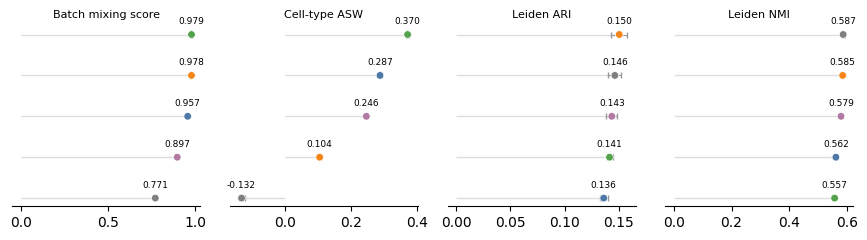

In [1]:
# Prefer the stored high-dimensional benchmark embeddings, then fall back to saved UMAP-only objects if needed.
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

N_REPEATS = 20
FRAC = 0.80
N_NEIGHBORS = 15
LEIDEN_RESOLUTION = 1.0
RANDOM_SEED = 20260514

METHOD_ORDER = ["Uncorrected", "Harmony", "Scanorama", "Seurat RPCA", "CONCORD"]
METHOD_COLORS = {
    "Uncorrected": "#7f7f7f",
    "Harmony": "#4c78a8",
    "Scanorama": "#f58518",
    "Seurat RPCA": "#54a24b",
    "CONCORD": "#b279a2",
}

HIGH_DIM_CANDIDATES = {
    "Uncorrected": [
        {"key": "X_uncorrected", "dims": 20, "metric": "euclidean"},
        {"key": "X_pca", "dims": 20, "metric": "euclidean"},
    ],
    "Harmony": [
        {"key": "X_harmony", "dims": 20, "metric": "euclidean"},
        {"key": "X_pca_harmony", "dims": 20, "metric": "euclidean"},
    ],
    "Scanorama": [
        {"key": "X_scanorama", "dims": 20, "metric": "euclidean"},
    ],
    "Seurat RPCA": [
        {"key": "X_seurat_rpca", "dims": 20, "metric": "euclidean"},
    ],
    "CONCORD": [
        {"key": "X_concord", "dims": 100, "metric": "cosine"},
    ],
}

UMAP_CANDIDATES = {
    "Uncorrected": [
        {"key": "X_umap_uncorrected", "dims": 2, "metric": "euclidean"},
        {"key": "X_umap", "dims": 2, "metric": "euclidean"},
    ],
    "Harmony": [
        {"key": "X_umap_harmony", "dims": 2, "metric": "euclidean"},
    ],
    "Scanorama": [
        {"key": "X_umap_scanorama", "dims": 2, "metric": "euclidean"},
    ],
    "Seurat RPCA": [
        {"key": "X_umap_seurat_rpca", "dims": 2, "metric": "euclidean"},
    ],
    "CONCORD": [
        {"key": "X_umap_concord", "dims": 2, "metric": "euclidean"},
    ],
}

def first_existing_obs_key(adata_obj, candidates, label):
    for key in candidates:
        if key in adata_obj.obs.columns:
            return key
    raise KeyError(
        f"Could not find {label} key. Tried: {candidates}. "
        f"Available obs keys: {list(adata_obj.obs.columns)}"
    )

def resolve_embeddings(adata_obj, candidates):
    resolved = {}
    for method, options in candidates.items():
        match = next((opt for opt in options if opt["key"] in adata_obj.obsm), None)
        if match is not None:
            resolved[method] = match.copy()
    return resolved

def choose_adata_for_resampling():
    sources = []
    if "adata_bench" in globals():
        sources.append(("adata_bench", adata_bench))
    if "adata_fig" in globals():
        sources.append(("adata_fig", adata_fig))
    if "adata" in globals():
        sources.append(("adata", adata))

    for name, obj in sources:
        resolved = resolve_embeddings(obj, HIGH_DIM_CANDIDATES)
        if len(resolved) >= 4:
            return obj.copy(), name, "highdim", resolved

    for name, obj in sources:
        resolved = resolve_embeddings(obj, UMAP_CANDIDATES)
        if len(resolved) >= 4:
            return obj.copy(), name, "umap", resolved

    saved_fig_path = Path("results/polished_figure_input.h5ad")
    if saved_fig_path.exists():
        obj = ad.read_h5ad(saved_fig_path)
        resolved = resolve_embeddings(obj, UMAP_CANDIDATES)
        if len(resolved) >= 4:
            return obj, str(saved_fig_path), "umap", resolved

    detail_lines = []
    for name, obj in sources:
        detail_lines.append(f"{name}: obsm keys = {list(obj.obsm.keys())}")
    if saved_fig_path.exists():
        obj = ad.read_h5ad(saved_fig_path)
        detail_lines.append(f"{saved_fig_path}: obsm keys = {list(obj.obsm.keys())}")
    raise KeyError(
        "Could not find a suitable AnnData object for resampling analysis.\n"
        + "\n".join(detail_lines)
    )

adata, ADATA_SOURCE, EMBEDDING_SOURCE, EMBEDDINGS = choose_adata_for_resampling()
print("Resampling AnnData source:", ADATA_SOURCE)
print("Embedding source type:", EMBEDDING_SOURCE)
print("Resolved methods:", EMBEDDINGS)
BATCH_KEY = first_existing_obs_key(adata, ["batch", "sample", "Batch"], "batch")
CELLTYPE_KEY = first_existing_obs_key(adata, ["celltype", "cell_type", "CellType", "label"], "cell type")


In [3]:
from pathlib import Path

# 如果 adata_bench 还不存在，就尝试用当前 notebook 里的对象重建
if "adata_bench" not in globals():
    required = ["adata_work", "adata_harmony", "adata_scanorama", "adata_seurat_rpca"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            f"这些对象还没在当前 kernel 中生成，无法重建 adata_bench: {missing}\n"
            "请先运行前面完成 batch correction / embedding 的单元。"
        )

    adata_bench = adata_work.copy()

    adata_bench.obsm["X_uncorrected"] = adata_work.obsm["X_pca"][:, :20].copy()
    adata_bench.obsm["X_harmony"] = adata_harmony.obsm["X_pca_harmony"][:, :20].copy()
    adata_bench.obsm["X_scanorama"] = adata_scanorama.obsm["X_scanorama"][:, :20].copy()
    adata_bench.obsm["X_seurat_rpca"] = adata_seurat_rpca.obsm["X_seurat_rpca"][:, :20].copy()

    if "adata_concord" in globals() and "X_concord" in adata_concord.obsm:
        adata_bench.obsm["X_concord"] = adata_concord.obsm["X_concord"].copy()

print("adata_bench 已就绪")
print("obs columns:", list(adata_bench.obs.columns))
print("obsm keys:", list(adata_bench.obsm.keys()))

out_path = Path("/home/training/20260507scRNA_RECOVERED/results/adata_bench_for_scib.h5ad")
adata_bench.write_h5ad(out_path)
print(f"saved to: {out_path}")

NameError: 这些对象还没在当前 kernel 中生成，无法重建 adata_bench: ['adata_work', 'adata_harmony', 'adata_scanorama', 'adata_seurat_rpca']
请先运行前面完成 batch correction / embedding 的单元。

In [2]:
from pathlib import Path

out_path = Path("/home/training/20260507scRNA_RECOVERED/results/adata_bench_for_scib.h5ad")

print("obsm keys:", list(adata_bench.obsm.keys()))
adata_bench.write_h5ad(out_path)
print(f"saved to: {out_path}")

NameError: name 'adata_bench' is not defined

## 12A. Descriptive paired tests on stored-embedding resamples

These non-parametric tests are included only as a descriptive check on ranking stability across the 20 matched stratified subsamples. They should not be interpreted as evidence of independent biological significance, because the subsamples are drawn from the same stored embeddings and therefore carry a pseudo-replication caveat.


In [ ]:
# Descriptive non-parametric tests for ranking stability across stored embeddings
# (subject to the pseudo-replication caveat noted in the markdown cell above).
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

resampling_long_path = Path('results/highdim_resampling/resampling_metrics_long_highdim.csv')
resampling_long_df = pd.read_csv(resampling_long_path)
celltype_test_df = (
    resampling_long_df[resampling_long_df['Method'].isin(['Harmony', 'Scanorama', 'Seurat RPCA'])]
    .pivot(index='repeat', columns='Method', values='Cell-type ASW')
    .sort_index()
)

friedman_result = friedmanchisquare(
    celltype_test_df['Harmony'],
    celltype_test_df['Scanorama'],
    celltype_test_df['Seurat RPCA'],
)
print(f"Friedman chi-square = {friedman_result.statistic:.2f}, p = {friedman_result.pvalue:.3e}")

pairwise_results = []
for method_a, method_b in [
    ('Harmony', 'Scanorama'),
    ('Harmony', 'Seurat RPCA'),
    ('Scanorama', 'Seurat RPCA'),
]:
    wilcoxon_result = wilcoxon(
        celltype_test_df[method_a],
        celltype_test_df[method_b],
        alternative='two-sided',
        zero_method='wilcox',
        correction=False,
        mode='auto',
    )
    pairwise_results.append({
        'Comparison': f'{method_a} vs {method_b}',
        'Statistic': float(wilcoxon_result.statistic),
        'Raw p': float(wilcoxon_result.pvalue),
        'Mean difference': float((celltype_test_df[method_a] - celltype_test_df[method_b]).mean()),
    })

pairwise_results_df = pd.DataFrame(pairwise_results)
pairwise_results_df['Holm-adjusted p'] = multipletests(pairwise_results_df['Raw p'], method='holm')[1]
print(pairwise_results_df)

print('Interpretation note: treat these as descriptive technical stability tests within one stored latent space, not as independent biological replication.')


Friedman chi-square = 33.60, p = 5.057e-08
               Comparison  Statistic     Raw p  Mean difference  Holm-adjusted p
0    Harmony vs Scanorama        0.0  0.000002         0.127329         0.000006
1  Harmony vs Seurat RPCA        0.0  0.000002         0.116899         0.000006
2  Scanorama vs Seurat RPCA      41.0  0.015312        -0.010430         0.015312
Interpretation note: treat these as descriptive technical stability tests within one stored latent space, not as independent biological replication.


# 13. Save final outputs for figures and report

Write the fixed metric tables, figure-ready CSVs, supplementary tables, and compact AnnData outputs used by the final report.


In [65]:
# Save the source-of-truth metric tables used by the report and plotting scripts.
import os

os.makedirs("results", exist_ok=True)

benchmark_df.to_csv("results/benchmark_metrics.csv", index=False)
rank_df.to_csv("results/benchmark_metrics_with_rank.csv", index=False)

for output_path in [
    "results/benchmark_metrics.csv",
    "results/benchmark_metrics_with_rank.csv",
]:
    print(output_path, os.path.exists(output_path))

print("Source of truth for final report metrics: results/benchmark_metrics.csv")
print(benchmark_df.set_index("method"))

benchmark_df


        method  batch_ASW_raw  batch_mixing_score  celltype_ASW  leiden_ARI  \
0  Uncorrected       0.324883            0.675117      0.076242    0.328166   
1      Harmony      -0.046959            0.953041      0.207071    0.414344   
2    Scanorama      -0.008477            0.991523      0.089482    0.332909   
3  Seurat RPCA       0.069046            0.930954      0.093004    0.404884   
4      CONCORD      -0.063023            0.936977      0.168827    0.307437   

   leiden_NMI  n_dimensions     metric  
0    0.661609            20  euclidean  
1    0.656870            20  euclidean  
2    0.678279            20  euclidean  
3    0.681139            20  euclidean  
4    0.662185           100     cosine  

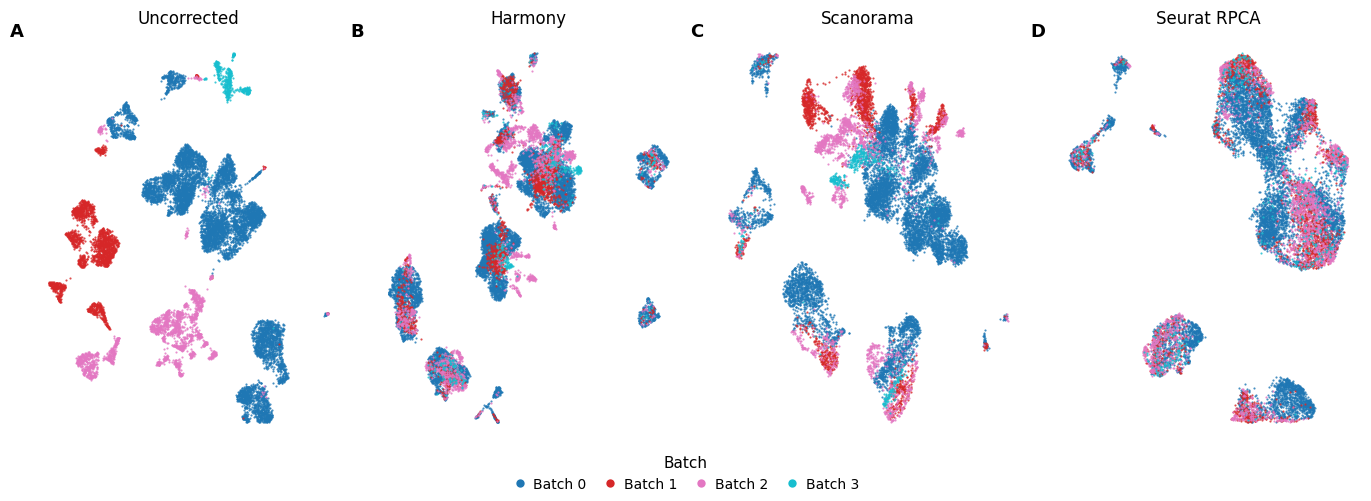

In [34]:
# Figure 1
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

os.makedirs("figures", exist_ok=True)

methods = [
    ("Uncorrected", adata_work, "X_umap_uncorrected"),
    ("Harmony", adata_harmony, "X_umap_harmony"),
    ("Scanorama", adata_scanorama, "X_umap_scanorama"),
    ("Seurat RPCA", adata_seurat_rpca, "X_umap_seurat_rpca"),
]

batch_cats = sorted(adata_work.obs[batch_key].astype(str).unique())
batch_colors = plt.cm.tab10(np.linspace(0, 1, len(batch_cats)))
batch_palette = dict(zip(batch_cats, batch_colors))

fig, axes = plt.subplots(1, 4, figsize=(13.6, 4.4), constrained_layout=True)
panel_labels = list("ABCD")

for i, (ax, (title, ad, key)) in enumerate(zip(axes, methods)):
    xy = ad.obsm[key]
    batch_values = ad.obs[batch_key].astype(str).values

    for batch in batch_cats:
        mask = batch_values == batch
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            c=[batch_palette[batch]],
            s=2.4,
            alpha=0.82,
            linewidths=0,
            rasterized=True
        )

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.text(
        -0.08, 1.03,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=6,
        markerfacecolor=batch_palette[b],
        markeredgecolor="none",
        label=f"Batch {b}"
    )
    for b in batch_cats
]

fig.legend(
    handles=handles,
    title="Batch",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=len(batch_cats),
    fontsize=10,
    title_fontsize=11,
    handletextpad=0.5,
    columnspacing=1.2
)

plt.savefig("figures/Figure1_umap_batch_main.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/Figure1_umap_batch_main.pdf", bbox_inches="tight")
plt.show()


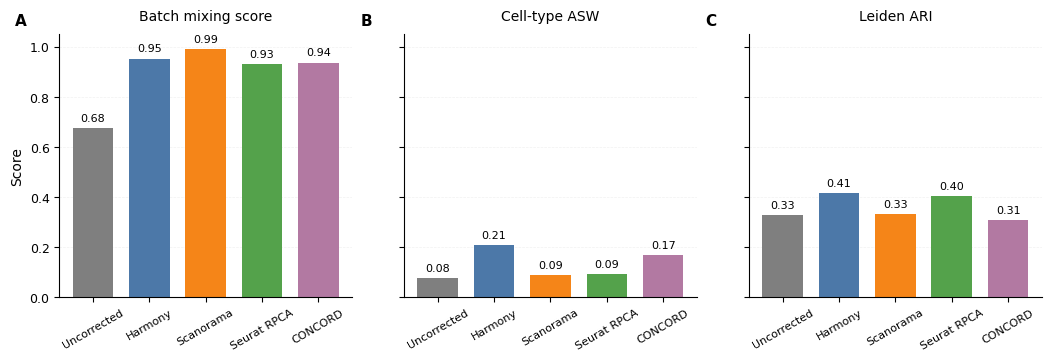

In [51]:
# Save the main Figure 2 summary tables directly from benchmark_df so report CSVs stay synchronized with the source metrics.
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

main_methods = ["Uncorrected", "Harmony", "Scanorama", "Seurat RPCA", "CONCORD"]
method_colors = {
    "Uncorrected": "#7f7f7f",
    "Harmony": "#4c78a8",
    "Scanorama": "#f58518",
    "Seurat RPCA": "#54a24b",
    "CONCORD": "#b279a2",
}

missing_methods = [m for m in main_methods if m not in benchmark_df["method"].values]
if missing_methods:
    raise ValueError(f"Missing benchmark results for: {missing_methods}. Run the CONCORD benchmark cells first.")

plot_df = (
    benchmark_df[benchmark_df["method"].isin(main_methods)]
    .set_index("method")
    .loc[main_methods, ["batch_mixing_score", "celltype_ASW", "leiden_ARI"]]
    .rename(columns={
        "batch_mixing_score": "Batch mixing score",
        "celltype_ASW": "Cell-type ASW",
        "leiden_ARI": "Leiden ARI",
    })
)

plot_wide_df = plot_df.reset_index().rename(columns={"method": "Method"})
plot_wide_df.to_csv("results/Figure2_benchmark_main_wide.csv", index=False)

plot_long_df = (
    plot_df.reset_index()
    .melt(id_vars="method", var_name="metric", value_name="score")
    .rename(columns={"method": "Method", "metric": "Metric", "score": "Score"})
)
plot_long_df["Method"] = pd.Categorical(plot_long_df["Method"], categories=main_methods, ordered=True)
plot_long_df["MethodColor"] = plot_long_df["Method"].map(method_colors)
plot_long_df.to_csv("results/Figure2_benchmark_main_long.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(10.4, 3.5), sharey=True, constrained_layout=True)

for i, (ax, metric) in enumerate(zip(axes, plot_df.columns)):
    values = plot_df[metric]
    bars = ax.bar(
        plot_df.index,
        values,
        color=[method_colors[m] for m in plot_df.index],
        width=0.72
    )

    ax.set_title(metric, fontsize=10, pad=10)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.18)
    ax.set_axisbelow(True)

    if i == 0:
        ax.set_ylabel("Score", fontsize=10)

    ax.text(
        -0.15, 1.08,
        chr(65 + i),
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.savefig("figures/Figure2_benchmark_main.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/Figure2_benchmark_main.pdf", bbox_inches="tight")
plt.show()

for output_path in [
    "results/Figure2_benchmark_main_wide.csv",
    "results/Figure2_benchmark_main_long.csv",
    "figures/Figure2_benchmark_main.png",
    "figures/Figure2_benchmark_main.pdf",
]:
    print(output_path, os.path.exists(output_path))


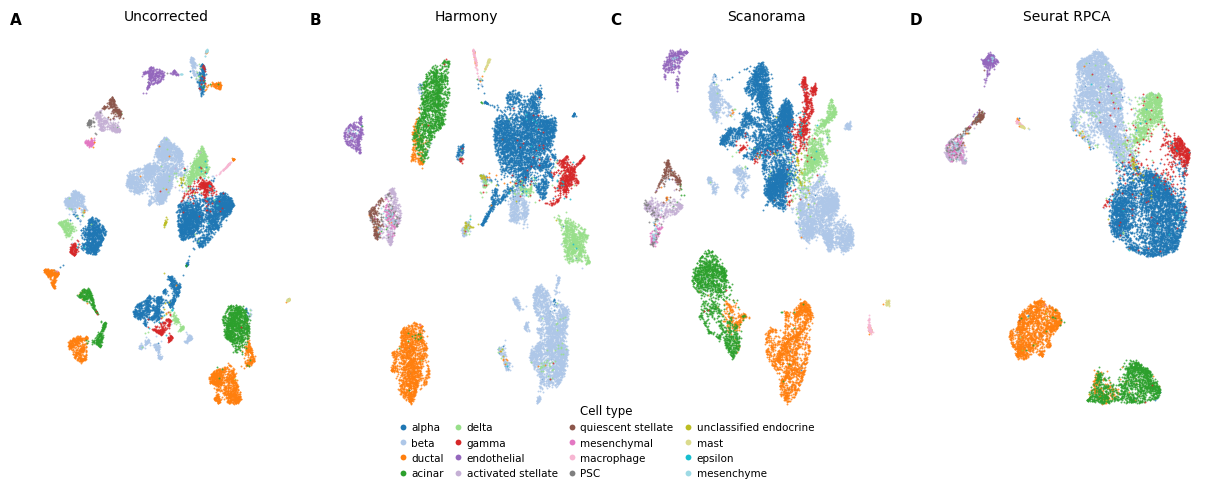

In [52]:
# Supplementary Figure S1
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

os.makedirs("figures", exist_ok=True)

methods = [
    ("Uncorrected", adata_work, "X_umap_uncorrected"),
    ("Harmony", adata_harmony, "X_umap_harmony"),
    ("Scanorama", adata_scanorama, "X_umap_scanorama"),
    ("Seurat RPCA", adata_seurat_rpca, "X_umap_seurat_rpca"),
]

celltype_order = adata_work.obs[label_key].value_counts().index.tolist()
celltype_colors = plt.cm.tab20(np.linspace(0, 1, len(celltype_order)))
celltype_palette = dict(zip(celltype_order, celltype_colors))

fig, axes = plt.subplots(1, 4, figsize=(14.4, 5.4), constrained_layout=True)
panel_labels = list("ABCD")

for i, (ax, (title, ad, key)) in enumerate(zip(axes, methods)):
    xy = ad.obsm[key]
    celltype_values = ad.obs[label_key].astype(str).values

    for celltype in celltype_order:
        mask = celltype_values == celltype
        if np.any(mask):
            ax.scatter(
                xy[mask, 0],
                xy[mask, 1],
                c=[celltype_palette[celltype]],
                s=2.1,
                alpha=0.82,
                linewidths=0,
                rasterized=True
            )

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.text(
        -0.08, 1.03,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="left",
        clip_on=False
    )

handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markersize=5.6,
        markerfacecolor=celltype_palette[ct],
        markeredgecolor="none",
        label=ct.replace("_", " ")
    )
    for ct in celltype_order
]

fig.legend(
    handles=handles,
    title="Cell type",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    fontsize=9,
    title_fontsize=10,
    ncol=4,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.savefig("figures/Supplementary_Figure_S1_umap_celltype.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/Supplementary_Figure_S1_umap_celltype.pdf", bbox_inches="tight")
plt.show()


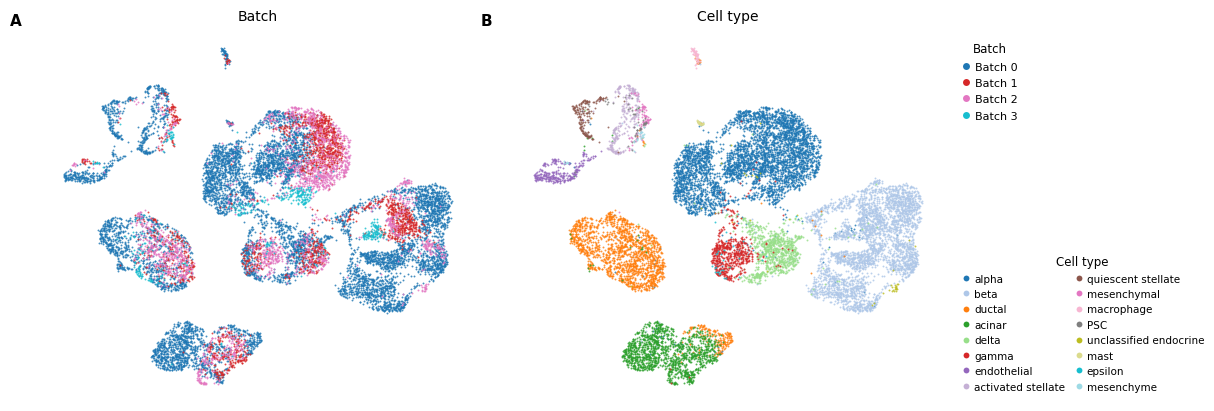

In [53]:
# Supplementary Figure S2
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

os.makedirs("figures", exist_ok=True)

if "adata_concord" not in globals() or "X_umap_concord" not in adata_concord.obsm:
    raise ValueError("CONCORD UMAP is not available. Run the CONCORD analysis cells first.")

batch_cats = sorted(adata_work.obs[batch_key].astype(str).unique())
batch_colors = plt.cm.tab10(np.linspace(0, 1, len(batch_cats)))
batch_palette = dict(zip(batch_cats, batch_colors))

celltype_order = adata_work.obs[label_key].value_counts().index.tolist()
celltype_colors = plt.cm.tab20(np.linspace(0, 1, len(celltype_order)))
celltype_palette = dict(zip(celltype_order, celltype_colors))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0), constrained_layout=True)
panel_labels = list("AB")
xy = adata_concord.obsm["X_umap_concord"]

batch_values = adata_concord.obs[batch_key].astype(str).values
for batch in batch_cats:
    mask = batch_values == batch
    axes[0].scatter(
        xy[mask, 0],
        xy[mask, 1],
        c=[batch_palette[batch]],
        s=2.1,
        alpha=0.82,
        linewidths=0,
        rasterized=True
    )
axes[0].set_title("Batch", fontsize=12, pad=8)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_frame_on(False)
axes[0].text(-0.08, 1.03, panel_labels[0], transform=axes[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left", clip_on=False)

celltype_values = adata_concord.obs[label_key].astype(str).values
for celltype in celltype_order:
    mask = celltype_values == celltype
    if np.any(mask):
        axes[1].scatter(
            xy[mask, 0],
            xy[mask, 1],
            c=[celltype_palette[celltype]],
            s=2.1,
            alpha=0.82,
            linewidths=0,
            rasterized=True
        )
axes[1].set_title("Cell type", fontsize=12, pad=8)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].set_frame_on(False)
axes[1].text(-0.08, 1.03, panel_labels[1], transform=axes[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left", clip_on=False)

batch_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=6, markerfacecolor=batch_palette[b], markeredgecolor="none", label=f"Batch {b}")
    for b in batch_cats
]
celltype_handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=5.6, markerfacecolor=celltype_palette[ct], markeredgecolor="none", label=ct.replace("_", " "))
    for ct in celltype_order
]

fig.legend(
    handles=batch_handles,
    title="Batch",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 0.94),
    fontsize=10,
    title_fontsize=11,
    handletextpad=0.4
)
fig.legend(
    handles=celltype_handles,
    title="Cell type",
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(1.01, 0.02),
    fontsize=9,
    title_fontsize=10,
    ncol=2,
    columnspacing=1.0,
    handletextpad=0.4
)

plt.savefig("figures/Supplementary_Figure_S2_concord_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/Supplementary_Figure_S2_concord_umap.pdf", bbox_inches="tight")
plt.show()


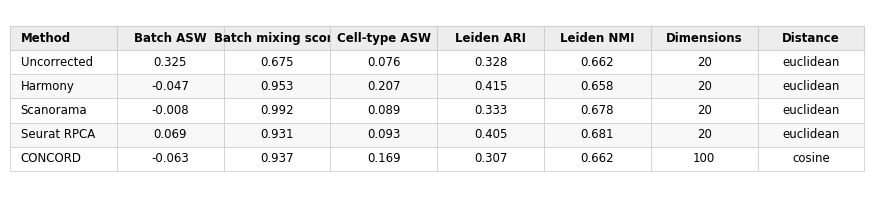

Saved results/Supplementary_Table_S1_full_benchmark.csv
Saved results/Supplementary_Table_S1_full_benchmark.xlsx
Saved results/Supplementary_Table_S1_full_benchmark.png


        Method  Batch ASW  Batch mixing score  Cell-type ASW  Leiden ARI  \
0  Uncorrected      0.325               0.675          0.076       0.328   
1      Harmony     -0.047               0.953          0.207       0.415   
2    Scanorama     -0.008               0.992          0.089       0.333   
3  Seurat RPCA      0.069               0.931          0.093       0.405   
4      CONCORD     -0.063               0.937          0.169       0.307   

   Leiden NMI  Dimensions   Distance  
0       0.662          20  euclidean  
1       0.658          20  euclidean  
2       0.678          20  euclidean  
3       0.681          20  euclidean  
4       0.662         100     cosine  

In [54]:
# Save the supplementary benchmark table in report-friendly formats from the same benchmark_df object.
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment

rcParams["font.family"] = "DejaVu Sans"
os.makedirs("results", exist_ok=True)

method_order = ["Uncorrected", "Harmony", "Scanorama", "Seurat RPCA", "CONCORD"]

supp_table = (
    benchmark_df[benchmark_df["method"].isin(method_order)]
    .set_index("method")
    .loc[method_order, [
        "batch_ASW_raw",
        "batch_mixing_score",
        "celltype_ASW",
        "leiden_ARI",
        "leiden_NMI",
        "n_dimensions",
        "metric",
    ]]
    .reset_index()
    .rename(columns={
        "method": "Method",
        "batch_ASW_raw": "Batch ASW",
        "batch_mixing_score": "Batch mixing score",
        "celltype_ASW": "Cell-type ASW",
        "leiden_ARI": "Leiden ARI",
        "leiden_NMI": "Leiden NMI",
        "n_dimensions": "Dimensions",
        "metric": "Distance",
    })
)

numeric_cols = [
    "Batch ASW",
    "Batch mixing score",
    "Cell-type ASW",
    "Leiden ARI",
    "Leiden NMI",
]
supp_table[numeric_cols] = supp_table[numeric_cols].round(3)

csv_path = "results/Supplementary_Table_S1_full_benchmark.csv"
xlsx_path = "results/Supplementary_Table_S1_full_benchmark.xlsx"
png_path = "results/Supplementary_Table_S1_full_benchmark.png"

supp_table.to_csv(csv_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    supp_table.to_excel(writer, index=False, sheet_name="Table S1")

wb = load_workbook(xlsx_path)
ws = wb["Table S1"]

header_fill = PatternFill(fill_type="solid", fgColor="EDEDED")
alt_fill = PatternFill(fill_type="solid", fgColor="F8F8F8")
white_fill = PatternFill(fill_type="solid", fgColor="FFFFFF")
thin_gray = Side(style="thin", color="CFCFCF")
header_border = Border(top=thin_gray, bottom=thin_gray)
body_border = Border(bottom=thin_gray)

for cell in ws[1]:
    cell.font = Font(bold=True, name="Arial", size=10)
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center", vertical="center")
    cell.border = header_border

for row in range(2, ws.max_row + 1):
    fill = alt_fill if row % 2 == 0 else white_fill
    for cell in ws[row]:
        cell.font = Font(name="Arial", size=10)
        cell.fill = fill
        cell.border = body_border
        if cell.column == 1:
            cell.alignment = Alignment(horizontal="left", vertical="center")
        else:
            cell.alignment = Alignment(horizontal="center", vertical="center")

widths = {
    "A": 18,
    "B": 12,
    "C": 18,
    "D": 14,
    "E": 12,
    "F": 12,
    "G": 12,
    "H": 12,
}
for col, width in widths.items():
    ws.column_dimensions[col].width = width

ws.freeze_panes = "A2"
wb.save(xlsx_path)

fig, ax = plt.subplots(figsize=(10.5, 2.3))
ax.axis("off")

display_table = supp_table.copy()
display_table["Dimensions"] = display_table["Dimensions"].astype(int).astype(str)

table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    loc="center",
    cellLoc="center",
    colLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.05, 1.45)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#CFCFCF")
    if row == 0:
        cell.set_facecolor("#EDEDED")
        cell.set_text_props(weight="bold")
        cell.set_linewidth(0.8)
    else:
        cell.set_facecolor("#F8F8F8" if row % 2 == 0 else "white")
        cell.set_linewidth(0.6)
    if col == 0:
        cell.get_text().set_ha("left")

plt.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

for output_path in [csv_path, xlsx_path, png_path]:
    print(output_path, os.path.exists(output_path))

supp_table


In [66]:
# Save a compact AnnData object containing only the final UMAP coordinates needed for polished figure generation.
import os
import scanpy as sc

adata_fig = adata_work.copy()

assert adata_fig.obs_names.equals(adata_harmony.obs_names)
assert adata_fig.obs_names.equals(adata_scanorama.obs_names)
assert adata_fig.obs_names.equals(adata_seurat_rpca.obs_names)
assert adata_fig.obs_names.equals(adata_concord.obs_names)

adata_fig.obsm["X_umap_uncorrected"] = adata_work.obsm["X_umap_uncorrected"].copy()
adata_fig.obsm["X_umap_harmony"] = adata_harmony.obsm["X_umap_harmony"].copy()
adata_fig.obsm["X_umap_scanorama"] = adata_scanorama.obsm["X_umap_scanorama"].copy()
adata_fig.obsm["X_umap_seurat_rpca"] = adata_seurat_rpca.obsm["X_umap_seurat_rpca"].copy()
adata_fig.obsm["X_umap_concord"] = adata_concord.obsm["X_umap_concord"].copy()

out_h5ad = "/home/training/20260507scRNA_RECOVERED/results/polished_figure_input.h5ad"
adata_fig.write_h5ad(out_h5ad)

print(adata_fig)
print(list(adata_fig.obsm.keys()))
print(out_h5ad, os.path.exists(out_h5ad))


AnnData object with n_obs × n_vars = 13291 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3', 'mean', 'std'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_umap_uncorrected', 'X_umap_harmony', 'X_umap_scanorama', 'X_umap_seurat_rpca', 'X_umap_concord'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
['X_pca', 'X_umap', 'X_umap_uncorrected', 'X_umap_harmony', 'X_umap_scanorama', 'X_umap_seurat_rpca', 'X_umap_concord']


## Archived reference: exploratory Seurat CCA

This block is kept only for reference. Seurat CCA was not used in the final report or final benchmark tables.


In [18]:
adata_cca = adata_work.copy()

ov.single.batch_correction(
    adata_cca,
    batch_key=batch_key,
    methods="cca"
)

print(adata_cca.obsm.keys())

...Begin using cca to correct batch effect
Not supported

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 0.001s                                                  │
│  Shape:    13,291 x 2,448 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
KeysView(AxisArrays with keys: X_pca, X_umap, X_umap_uncorrected)
